In [1]:
from pathlib import Path
import json
import datetime
import re
import hashlib
import os
import pickle as pkl
import joblib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import ruptures as rpt
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, SequentialFeatureSelector
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from tqdm.auto import tqdm
from sklearn.utils import resample
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    f1_score, make_scorer, get_scorer, roc_curve
)
from sklearn.calibration import calibration_curve

d:\venvs\StockX_Project-epBZGTuI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
variables_finales = [
    'retail_price',
    'pre_release_premium_pct',
    'brand_historical_rate',
    'brand_Jordan',
    'num_pre_release_points',
]

cols_scale_lin = [i for i in variables_finales if i != 'brand_Jordan']

TARGET = 'is_above_retail_90d'

In [3]:
root = Path('..')
data_folder = Path('data')
f_d = Path('ready_data.pkl')
lin = Path('ref_test_lin.pkl')

In [4]:
features = joblib.load(root/data_folder/f_d)
ref_test_lin = joblib.load(root/data_folder/lin)['ref_test_lin']

In [5]:
features.keys()
train_lin = features['train_data']
test_lin = features['test_data']

In [6]:
model_training_bundle = joblib.load('bundle_above_retail.pkl')
scaler_raw = model_training_bundle['scaler']
raw_cols = list(scaler_raw.feature_names_in_)

scaler_lin = RobustScaler()
scaler_lin.n_features_in_ = len(cols_scale_lin)
scaler_lin.feature_names_in_ = np.array(cols_scale_lin, dtype=object)
scaler_lin.center_ = np.array([scaler_raw.center_[raw_cols.index(c)] for c in cols_scale_lin])
scaler_lin.scale_  = np.array([scaler_raw.scale_[raw_cols.index(c)] for c in cols_scale_lin])

In [7]:
joblib.dump(scaler_lin, 'scaler_lin.pkl')

['scaler_lin.pkl']

In [8]:
train_lin = pd.get_dummies(train_lin, columns=['brand_grouped'], prefix='brand', drop_first=True)
test_lin  = pd.get_dummies(test_lin,  columns=['brand_grouped'], prefix='brand', drop_first=True)

train_lin, test_lin = train_lin.align(test_lin, join='left', axis=1, fill_value=0)

dummy_cols = [c for c in train_lin.columns if c.startswith('brand_') and c != 'brand_historical_rate']
train_lin[dummy_cols] = train_lin[dummy_cols].astype(int)
test_lin[dummy_cols]  = test_lin[dummy_cols].astype(int)

# ------- dates ---------
def add_cyclical_features(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

for d in [train_lin, test_lin]:
    add_cyclical_features(d, 'release_month', 12)
    add_cyclical_features(d, 'release_quarter', 4)
    add_cyclical_features(d, 'release_dow', 7)

train_lin = train_lin.drop(columns=['release_month', 'release_quarter', 'release_dow'])
test_lin  = test_lin.drop(columns=['release_month', 'release_quarter', 'release_dow'])

In [9]:
train_lin.info()

<class 'pandas.DataFrame'>
RangeIndex: 3271 entries, 0 to 3270
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        3271 non-null   object        
 1   retail_price                 3271 non-null   float64       
 2   release_date                 3271 non-null   datetime64[ns]
 3   brand                        3271 non-null   object        
 4   pre_release_premium_pct      3271 non-null   float64       
 5   is_above_retail_90d          3271 non-null   object        
 6   has_pre_release_speculation  3271 non-null   bool          
 7   num_pre_release_points       3271 non-null   float64       
 8   pre_release_volatility       3271 non-null   float64       
 9   pre_release_trend            3271 non-null   float64       
 10  days_speculation_window      3271 non-null   float64       
 11  release_year                 3271 non-null   int32    

In [10]:
X_train = train_lin[variables_finales].values
y_train = train_lin['is_above_retail_90d'].astype(int).values
X_test  = test_lin[variables_finales].values
y_test  = test_lin['is_above_retail_90d'].astype(int).values

In [11]:
train_lin[variables_finales].columns

Index(['retail_price', 'pre_release_premium_pct', 'brand_historical_rate',
       'brand_Jordan', 'num_pre_release_points'],
      dtype='str')

In [12]:
train_lin[variables_finales]

,retail_price,pre_release_premium_pct,brand_historical_rate,brand_Jordan,num_pre_release_points
0,1.076923,3.152273,2.768992,0,0.000000
1,1.076923,11.149545,2.768992,0,0.000000
2,-0.923077,0.000000,2.768992,0,-0.333333
3,-0.923077,0.000000,2.768992,0,-0.333333
4,-0.923077,0.000000,2.768992,0,-0.333333
...,...,...,...,...,...
3266,1.076923,0.000000,-0.045314,0,-0.333333
3267,0.461538,0.000000,-0.038859,0,-0.333333
3268,-0.076923,0.891034,-0.913954,0,6.666667
3269,-0.307692,2.923077,-0.907353,0,7.000000


In [13]:
modelo_final = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
modelo_final.fit(X_train, y_train)

d:\venvs\StockX_Project-epBZGTuI\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\venvs\StockX_Project-epBZGTuI\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Ta

═════════════════════════════════════════════════════════════════
OPTIMAL THRESHOLDS BY BUSINESS CRITERION
═════════════════════════════════════════════════════════════════

  A) Maximum F1:
     threshold=0.33 | P=0.592 R=0.791 F1=0.677 | predicts 478 pairs as 'above retail'

  B) Recall ≥ 0.60 (don't miss good pairs):
     threshold=0.43 | P=0.642 R=0.601 F1=0.620 | predicts 335 pairs as 'above retail'

  C) Precision ≥ 0.75 (don't buy bad pairs):
     threshold=0.55 | P=0.812 R=0.302 F1=0.440 | predicts 133 pairs as 'above retail'

═════════════════════════════════════════════════════════════════
RANKING ANALYSIS — real rate in top-K pairs
═════════════════════════════════════════════════════════════════
  (Base rate on test: 43.8%)

       K  Above retail in top-K     Lift
  ────────────────────────────────────────
      10                  90.0%     2.06x
      25                  96.0%     2.19x
      50                  94.0%     2.15x
     100                  85.0%     1.94x
 

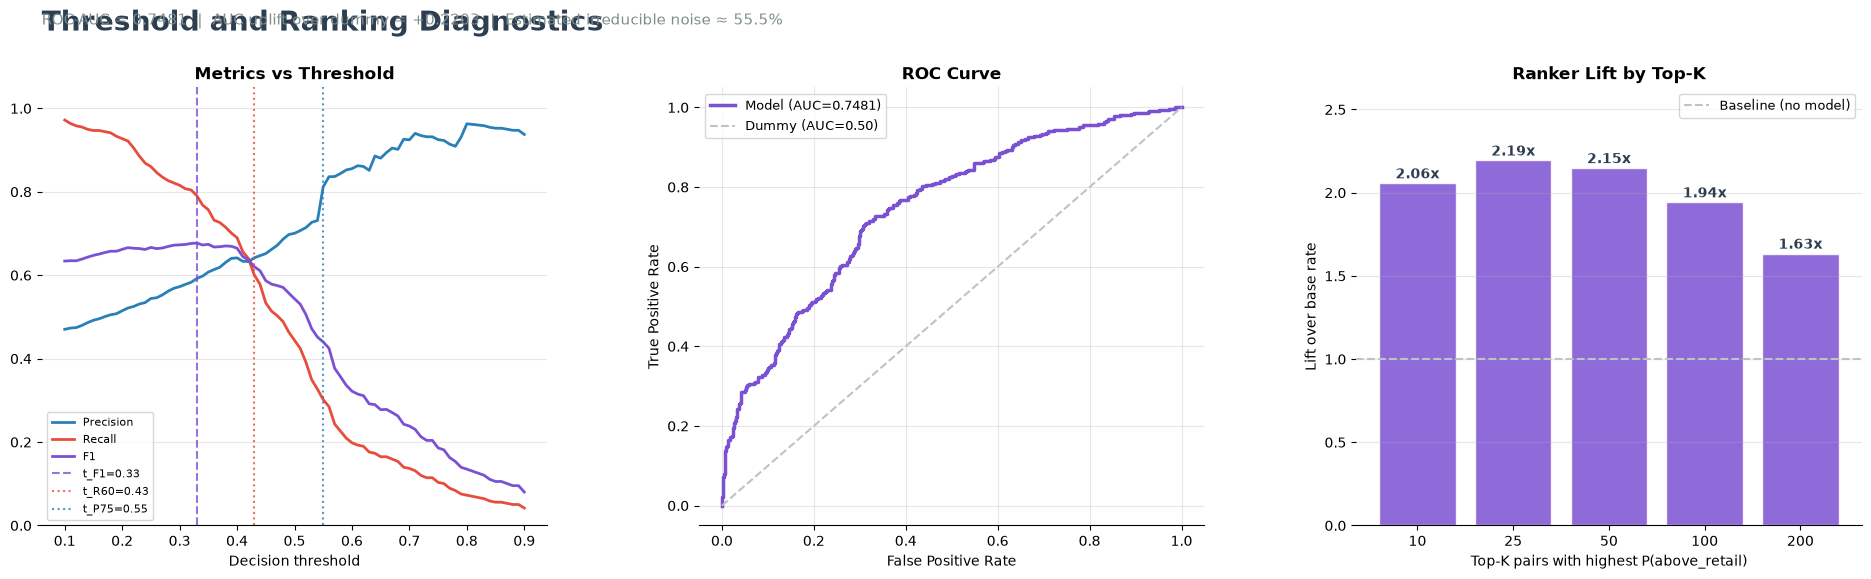

In [14]:
# ============================================================
# 1. MODEL PROBABILITIES ON TEST
# ============================================================
y_proba = modelo_final.predict_proba(X_test)[:, 1]


# Threshold Simulation

thresholds = np.arange(0.10, 0.91, 0.01)
resultados_thresh = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    pred_positivos = y_pred_t.sum()
    if pred_positivos == 0:
        continue
    resultados_thresh.append({
        'threshold':  t,
        'precision':  precision_score(y_test, y_pred_t, zero_division=0),
        'recall':     recall_score(y_test, y_pred_t, zero_division=0),
        'f1':         f1_score(y_test, y_pred_t, zero_division=0),
        'n_predicted_positive': pred_positivos,
    })

df_thresh = pd.DataFrame(resultados_thresh)

# Threshold A: maximum F1
idx_f1 = df_thresh['f1'].idxmax()
t_f1   = df_thresh.loc[idx_f1]

# Threshold B: recall >= 0.60, highest possible precision
candidates_b = df_thresh[df_thresh['recall'] >= 0.60]
t_recall = candidates_b.loc[candidates_b['precision'].idxmax()] if not candidates_b.empty else None

# Threshold C: precision >= 0.75, highest possible recall
candidates_c = df_thresh[df_thresh['precision'] >= 0.75]
t_precision = candidates_c.loc[candidates_c['recall'].idxmax()] if not candidates_c.empty else None

print("═" * 65)
print("OPTIMAL THRESHOLDS BY BUSINESS CRITERION")
print("═" * 65)
print(f"\n  A) Maximum F1:")
print(f"     threshold={t_f1['threshold']:.2f} | "
      f"P={t_f1['precision']:.3f} R={t_f1['recall']:.3f} F1={t_f1['f1']:.3f} | "
      f"predicts {t_f1['n_predicted_positive']:.0f} pairs as 'above retail'")

if t_recall is not None:
    print(f"\n  B) Recall ≥ 0.60 (don't miss good pairs):")
    print(f"     threshold={t_recall['threshold']:.2f} | "
          f"P={t_recall['precision']:.3f} R={t_recall['recall']:.3f} F1={t_recall['f1']:.3f} | "
          f"predicts {t_recall['n_predicted_positive']:.0f} pairs as 'above retail'")

if t_precision is not None:
    print(f"\n  C) Precision ≥ 0.75 (don't buy bad pairs):")
    print(f"     threshold={t_precision['threshold']:.2f} | "
          f"P={t_precision['precision']:.3f} R={t_precision['recall']:.3f} F1={t_precision['f1']:.3f} | "
          f"predicts {t_precision['n_predicted_positive']:.0f} pairs as 'above retail'")

# ============================================================
# 3. THE MODEL AS A RANKER — do the top-K have a higher real rate?
# ============================================================
df_ranker = pd.DataFrame({
    'proba':         y_proba,
    'real':          y_test,
    'title':         ref_test_lin.loc[test_lin.index, 'title'].values,
}).sort_values('proba', ascending=False).reset_index(drop=True)

K_values = [10, 25, 50, 100, 200]
print("\n" + "═" * 65)
print("RANKING ANALYSIS — real rate in top-K pairs")
print("═" * 65)
print(f"  (Base rate on test: {y_test.mean():.1%})\n")
print(f"  {'K':>6} {'Above retail in top-K':>22} {'Lift':>8}")
print("  " + "─" * 40)
for k in K_values:
    tasa_k = df_ranker.head(k)['real'].mean()
    lift   = tasa_k / y_test.mean()
    print(f"  {k:>6} {tasa_k:>22.1%} {lift:>8.2f}x")

# ============================================================
# 4. VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.text(0.06, 0.98, "Threshold and Ranking Diagnostics", fontsize=20,
          fontweight='bold', color='#2c3e50', va='top')
fig.text(0.06, 0.955,
          f"ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}  |  "
          f"AUC uplift over dummy = +0.2203  |  "
          f"Estimated irreducible noise ≈ 55.5%",
          fontsize=11, color='#7f8c8d')

# Panel 1 — Precision / Recall / F1 vs threshold
ax = axes[0]
ax.plot(df_thresh['threshold'], df_thresh['precision'],
        color='#2980b9', linewidth=2, label='Precision')
ax.plot(df_thresh['threshold'], df_thresh['recall'],
        color='#e74c3c', linewidth=2, label='Recall')
ax.plot(df_thresh['threshold'], df_thresh['f1'],
        color='#7b51d3', linewidth=2, label='F1')
ax.axvline(t_f1['threshold'], color='#7b51d3', linestyle='--',
            linewidth=1.5, alpha=0.8, label=f"t_F1={t_f1['threshold']:.2f}")
if t_recall is not None:
    ax.axvline(t_recall['threshold'], color='#e74c3c', linestyle=':',
                linewidth=1.5, alpha=0.8, label=f"t_R60={t_recall['threshold']:.2f}")
if t_precision is not None:
    ax.axvline(t_precision['threshold'], color='#2980b9', linestyle=':',
                linewidth=1.5, alpha=0.8, label=f"t_P75={t_precision['threshold']:.2f}")
ax.set_xlabel('Decision threshold')
ax.set_title('Metrics vs Threshold', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
sns.despine(left=True, ax=ax)

# Panel 2 — ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, color='#7b51d3', linewidth=2.5,
        label=f'Model (AUC={roc_auc_score(y_test, y_proba):.4f})')
ax.plot([0, 1], [0, 1], color='#bdc3c7', linestyle='--', linewidth=1.5, label='Dummy (AUC=0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
sns.despine(left=True, ax=ax)

# Panel 3 — Ranker lift by top-K
ax = axes[2]
tasas_k = [df_ranker.head(k)['real'].mean() for k in K_values]
lifts_k = [t / y_test.mean() for t in tasas_k]
ax.bar([str(k) for k in K_values], lifts_k,
        color='#7b51d3', alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='#bdc3c7', linestyle='--', linewidth=1.5, label='Baseline (no model)')
for i, (k, lift) in enumerate(zip(K_values, lifts_k)):
    ax.text(i, lift + 0.03, f'{lift:.2f}x', ha='center', fontsize=10,
            fontweight='bold', color='#2c3e50')
ax.set_xlabel('Top-K pairs with highest P(above_retail)')
ax.set_ylabel('Lift over base rate')
ax.set_title('Ranker Lift by Top-K', fontweight='bold')
ax.set_ylim(0, max(lifts_k) * 1.2)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine(left=True, ax=ax)

plt.subplots_adjust(top=0.85, left=0.06, right=0.97, bottom=0.12, wspace=0.3)
plt.show()

In [15]:
# ============================================================
# 1. LOAD BUNDLE
# ============================================================
bundle    = joblib.load('bundle_above_retail.pkl')
modelo    = bundle['modelo']
variables = bundle['variables']

# Historical rates by brand (precomputed during training)
brand_rates = bundle.get('brand_historical_rates', {
    'Jordan':      0.82,
    'Nike':        0.61,
    'Yeezy':       0.74,
    'Adidas':      0.53,
    'New Balance': 0.58,
    'Puma':        0.41,
    'ASICS':       0.44,
    'Onitsuka':    0.39,
    'Vans':        0.30,
    'Other':       0.45,
})

MARCAS = list(brand_rates.keys())

# ============================================================
# 2. USER INPUTS
# ============================================================
print("=" * 55)
print("  RESALE PREDICTOR — is_above_retail_90d")
print("=" * 55)

# --- Brand ---
print("\nAvailable brands:")
for i, m in enumerate(MARCAS, 1):
    print(f"  {i}. {m}")
while True:
    try:
        idx_marca = int(input("\nSelect the brand number: ")) - 1
        marca = MARCAS[idx_marca]
        break
    except (ValueError, IndexError):
        print("  Invalid option, try again.")

# --- Retail price ---
while True:
    try:
        retail_price = float(input("Retail price (USD): $"))
        if retail_price > 0:
            break
        print("  Must be greater than 0.")
    except ValueError:
        print("  Enter a valid number.")

# --- Pre-release peak ---
print("\n  (If there was no pre-release speculation, enter 0)")
while True:
    try:
        pre_release_peak = float(input("Pre-release peak price (USD): $"))
        if pre_release_peak >= 0:
            break
        print("  Must be greater than or equal to 0.")
    except ValueError:
        print("  Enter a valid number.")

# --- Num pre-release points ---
while True:
    try:
        num_pre_release_points = int(input("Number of pre-release price records: "))
        if num_pre_release_points >= 0:
            break
        print("  Must be greater than or equal to 0.")
    except ValueError:
        print("  Enter a valid integer.")

# ============================================================
# 3. DERIVE FEATURES (same as in training)
# ============================================================
pre_release_premium_pct = (
    (pre_release_peak - retail_price) / retail_price * 100
    if retail_price > 0 and pre_release_peak > 0
    else 0.0
)
brand_historical_rate = brand_rates.get(marca, brand_rates['Other'])
brand_Jordan          = int(marca == 'Jordan')

# ============================================================
# 4. BUILD VECTOR IN THE EXACT ORDER EXPECTED BY THE MODEL
# ============================================================
input_dict = {
    'retail_price':             retail_price,
    'pre_release_premium_pct':  pre_release_premium_pct,
    'brand_historical_rate':    brand_historical_rate,
    'brand_Jordan':             brand_Jordan,
    'num_pre_release_points':   num_pre_release_points,
}
X_raw       = pd.DataFrame([input_dict])[variables]
X_scaled    = scaler_lin.transform(X_raw[cols_scale_lin])
X_scaled_df = pd.DataFrame(X_scaled, columns=cols_scale_lin, index=X_raw.index)
# Reindex to `variables` order -- concat alone leaves brand_Jordan last,
# which doesn't match the column order the model was trained on.
X_scaled    = pd.concat([X_scaled_df, X_raw[['brand_Jordan']]], axis=1)[variables]

# ============================================================
# 5. PREDICTION
# ============================================================
proba     = modelo.predict_proba(X_scaled.values)[0, 1]
pred_bin  = int(proba >= bundle.get('umbral', 0.43))

# Confidence level
if proba >= 0.85:
    confianza = "VERY HIGH ✅"
elif proba >= 0.70:
    confianza = "HIGH      ✅"
elif proba >= 0.50:
    confianza = "MEDIUM    ⚠️"
else:
    confianza = "LOW       ❌"

# ============================================================
# 6. OUTPUT
# ============================================================
print("\n" + "=" * 55)
print("  INPUT SUMMARY")
print("=" * 55)
print(f"  Brand:                   {marca}")
print(f"  Retail price:            ${retail_price:,.0f}")
print(f"  Pre-release peak:        ${pre_release_peak:,.0f}")
print(f"  Pre-release premium:     {pre_release_premium_pct:.1f}%  [calculated]")
print(f"  Brand historical rate:   {brand_historical_rate:.1%}  [calculated]")
print(f"  Brand Jordan:            {brand_Jordan}              [calculated]")
print(f"  Num pre-release points:  {num_pre_release_points}")

print("\n" + "=" * 55)
print("  PREDICTION")
print("=" * 55)
print(f"  P(above retail at 90d):  {proba:.1%}")
print(f"  Confidence:              {confianza}")
print(f"  Decision (t=0.43):       {'ABOVE RETAIL' if pred_bin else 'BELOW RETAIL'}")
print(f"\n  Suggested ranking:       {'Top candidate 🔥' if proba >= 0.85 else 'Medium candidate ⚠️' if proba >= 0.60 else 'Discard ❌'}")
print("=" * 55)

  RESALE PREDICTOR — is_above_retail_90d

Available brands:
  1. Jordan
  2. Nike
  3. Yeezy
  4. Adidas
  5. New Balance
  6. Puma
  7. ASICS
  8. Onitsuka
  9. Vans
  10. Other

  (If there was no pre-release speculation, enter 0)

  INPUT SUMMARY
  Brand:                   Nike
  Retail price:            $200
  Pre-release peak:        $500
  Pre-release premium:     150.0%  [calculated]
  Brand historical rate:   61.0%  [calculated]
  Brand Jordan:            0              [calculated]
  Num pre-release points:  20

  PREDICTION
  P(above retail at 90d):  52.8%
  Confidence:              MEDIUM    ⚠️
  Decision (t=0.43):       ABOVE RETAIL

  Suggested ranking:       Discard ❌


## 7. Probability calibration (deployment bundle)

The raw `LogisticRegression` outputs overconfident probabilities pushed toward the extremes (see the interactive predictor above: 100.0%). Wrapping it in `CalibratedClassifierCV` recalibrates `predict_proba` against the true empirical likelihoods, then the deployment bundle is re-saved with the calibrated model.

Note: **CalibratedClassifierCV** deletes the old coefficients and refits the model n times. In other words re-trains the model.

In [16]:
from sklearn.calibration import CalibratedClassifierCV

modelo_base = modelo_final

modelo_final = CalibratedClassifierCV(estimator=modelo_base, method='sigmoid', cv=5)
modelo_final.fit(X_train, y_train)

d:\venvs\StockX_Project-epBZGTuI\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\venvs\StockX_Project-epBZGTuI\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\venvs\StockX_Project-epBZGTuI\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of p

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...r='liblinear')
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001D8AA5089B0>, <sk

In [17]:
bundle_calibrated = {
    'modelo': modelo_final,
    'scaler': scaler_lin,
    'variables': variables_finales,
}
joblib.dump(bundle_calibrated, 'bundle_above_retail.pkl')

['bundle_above_retail.pkl']

## 8. Regression test — probabilities must not collapse to {0, 1}

Reloads the bundle just saved to disk (the exact artifact `app/inference.py` would load) and scores a handful of varied inputs. If the scaler ever becomes a stale/no-op identity again (the bug this notebook was fixed for), every probability saturates to exactly 0.0 or 1.0 and the assertions below fail.

In [18]:
bundle_check     = joblib.load('bundle_above_retail.pkl')
modelo_check     = bundle_check['modelo']
scaler_check     = bundle_check['scaler']
variables_check  = bundle_check['variables']
cols_scale_check = [v for v in variables_check if v != 'brand_Jordan']

# Self-contained (doesn't depend on the interactive predictor cell having
# been run) so this check works even in a non-interactive execution.
brand_rates_check = bundle_check.get('brand_historical_rates', {
    'Jordan': 0.82, 'Nike': 0.61, 'Yeezy': 0.74, 'Adidas': 0.53,
    'New Balance': 0.58, 'Puma': 0.41, 'ASICS': 0.44, 'Onitsuka': 0.39,
    'Vans': 0.30, 'Other': 0.45,
})

test_cases = [
    {'retail_price': 170, 'pre_release_peak': 0,   'marca': 'Nike',   'num_pre_release_points': 0},
    {'retail_price': 170, 'pre_release_peak': 200, 'marca': 'Nike',   'num_pre_release_points': 3},
    {'retail_price': 220, 'pre_release_peak': 900, 'marca': 'ASICS',  'num_pre_release_points': 2},
    {'retail_price': 100, 'pre_release_peak': 100, 'marca': 'Adidas', 'num_pre_release_points': 1},
    {'retail_price': 150, 'pre_release_peak': 160, 'marca': 'Puma',   'num_pre_release_points': 2},
    {'retail_price': 200, 'pre_release_peak': 210, 'marca': 'Jordan', 'num_pre_release_points': 5},
    {'retail_price': 150, 'pre_release_peak': 0,   'marca': 'Vans',   'num_pre_release_points': 0},
]


def score(case):
    premium = (
        (case['pre_release_peak'] - case['retail_price']) / case['retail_price'] * 100
        if case['retail_price'] > 0 and case['pre_release_peak'] > 0 else 0.0
    )
    row = {
        'retail_price':            case['retail_price'],
        'pre_release_premium_pct': premium,
        'brand_historical_rate':   brand_rates_check.get(case['marca'], brand_rates_check['Other']),
        'brand_Jordan':            int(case['marca'] == 'Jordan'),
        'num_pre_release_points':  case['num_pre_release_points'],
    }
    X_raw = pd.DataFrame([row])[variables_check]
    X_num_scaled = pd.DataFrame(
        scaler_check.transform(X_raw[cols_scale_check]), columns=cols_scale_check
    )
    X_final = pd.concat([X_num_scaled, X_raw[['brand_Jordan']]], axis=1)[variables_check]
    return float(modelo_check.predict_proba(X_final.values)[0, 1])


print(f"{'Brand':<12} {'Retail':>8} {'Peak':>8}   P(above_retail_90d)")
probas = []
for case in test_cases:
    p = score(case)
    probas.append(p)
    print(f"{case['marca']:<12} ${case['retail_price']:>6.0f} ${case['pre_release_peak']:>6.0f}   {p:.1%}")

n_unique = len({round(p, 3) for p in probas})
assert n_unique > 1, "All test probabilities are identical -- the scaler/model pipeline is broken."
assert any(0.02 < p < 0.98 for p in probas), (
    "Every prediction saturated to ~0 or ~1 -- this is the double-scaling regression, check the scaler."
)
print(f"\nOK -- {n_unique} distinct probabilities across {len(test_cases)} cases, "
      f"range [{min(probas):.1%}, {max(probas):.1%}].")

Brand          Retail     Peak   P(above_retail_90d)
Nike         $   170 $     0   42.9%
Nike         $   170 $   200   43.6%
ASICS        $   220 $   900   88.9%
Adidas       $   100 $   100   45.7%
Puma         $   150 $   160   24.5%
Jordan       $   200 $   210   30.6%
Vans         $   150 $     0   17.7%

OK -- 7 distinct probabilities across 7 cases, range [17.7%, 88.9%].


## 9. Final metrics summary (table)

Reloads the saved bundle and reports the deployed (calibrated) model's test-set performance as a single table — classification metrics at the deployment threshold plus ranker lift at each Top-K, no charts.

In [19]:
from sklearn.metrics import accuracy_score

bundle_summary    = joblib.load('bundle_above_retail.pkl')
modelo_summary    = bundle_summary['modelo']
umbral_summary    = bundle_summary.get('umbral', 0.43)

y_proba_summary = modelo_summary.predict_proba(X_test)[:, 1]
y_pred_summary  = (y_proba_summary >= umbral_summary).astype(int)

base_rate = y_test.mean()
K_values  = [10, 25, 50, 100, 200]
df_ranker_summary = pd.DataFrame({
    'proba': y_proba_summary,
    'real':  y_test,
}).sort_values('proba', ascending=False).reset_index(drop=True)

rows = [
    {'metric': 'N test samples',    'value': len(y_test)},
    {'metric': 'Base rate (test)',  'value': base_rate},
    {'metric': 'Decision threshold', 'value': umbral_summary},
    {'metric': 'Accuracy',          'value': accuracy_score(y_test, y_pred_summary)},
    {'metric': 'Precision',         'value': precision_score(y_test, y_pred_summary, zero_division=0)},
    {'metric': 'Recall',            'value': recall_score(y_test, y_pred_summary, zero_division=0)},
    {'metric': 'F1',                'value': f1_score(y_test, y_pred_summary, zero_division=0)},
    {'metric': 'ROC-AUC',           'value': roc_auc_score(y_test, y_proba_summary)},
]
for k in K_values:
    tasa_k = df_ranker_summary.head(k)['real'].mean()
    rows.append({'metric': f'Lift @ Top-{k}', 'value': tasa_k / base_rate})

df_metrics_summary = pd.DataFrame(rows).set_index('metric')
df_metrics_summary['value'] = df_metrics_summary['value'].round(4)
df_metrics_summary

,value
metric,
N test samples,818.0000
Base rate (test),0.4377
Decision threshold,0.4300
Accuracy,0.6711
Precision,0.6529
Recall,0.5307
F1,0.5855
ROC-AUC,0.7491
Lift @ Top-10,2.0564
